# Docker for model services — the hands-on half

The practical companion to **`docker_slides.html`**. Every image in this notebook is really
built, really measured, and really run — you will watch a 1.5 GB image become 250 MB, and see
a rebuild drop from a minute to under a second.

| Part | Deck slides | What you do |
|---|---|---|
| 0 · Setup | 10 | check Docker, sandbox, write the app to containerise |
| 1 · First image | 11–13 | a naive `Dockerfile`, built and measured |
| 2 · Make it smaller | 14–17 | `.dockerignore`, slim base, multi-stage — measured each time |
| 3 · Make it faster | 18–21 | layer caching, and the one line order that matters |
| 4 · Run it | 22–24 | ports, env vars, volumes, healthcheck, non-root |
| 5 · Compose & ship | 25–27 | `docker compose`, registries, images in CI |

**The problem this solves:** "it works on my machine" is not a deployment strategy. A container
is your code, your dependencies and your Python version in one artifact that runs the same
anywhere.

Everything happens in a throwaway `docker_demo/` folder; the last cell removes it **and the
images built here**, so this notebook leaves nothing behind.

## Step 0.1 · Is Docker there?

In [1]:
!docker --version
!docker compose version
print()
!docker info --format 'server version {{.ServerVersion}} | containers {{.Containers}} | images {{.Images}}'

Docker version 29.6.1, build 8900f1d
Docker Compose version v5.3.0

server version {.ServerVersion} | containers {.Containers} | images {.Images}


> If `docker info` errors, the daemon is not running (`sudo systemctl start docker`) or your user
> is not in the `docker` group (`sudo usermod -aG docker $USER`, then log out and in). Everything
> below needs a working daemon.

## Step 0.2 · A sandbox to work in

In [2]:
import os, shutil, pathlib

BASE = pathlib.Path.cwd()          # the folder this notebook lives in
PROJ = BASE / "docker_demo"           # a throwaway sandbox, deleted by the last cell

if PROJ.exists():
    shutil.rmtree(PROJ)            # re-running this notebook is always safe
PROJ.mkdir(parents=True)
os.chdir(PROJ)
print("working inside:", os.getcwd())

working inside: /home/shamaseen/Desktop/Shai/qafza/free_Training/qafza-free-traning/04-docker/docker_demo


## Step 0.3 · The thing we are going to containerise

A trimmed version of session 3's API. Written out here so this session stands alone.

In [3]:
import os
os.makedirs("app", exist_ok=True)

First, something worth containerising: the small prediction API from session 3. Nothing new here
— it is the payload for everything below.

In [4]:
%%writefile app/main.py
"""A small model API -- the artifact we are going to package."""
import os
import joblib
import pandas as pd
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, ConfigDict, Field
from typing import Literal, Optional

MODEL_PATH = os.getenv("MODEL_PATH", "app/model.joblib")
STATE = {}

app = FastAPI(title="Churn API", version="1.0.0")


class Customer(BaseModel):
    model_config = ConfigDict(extra="forbid")
    tenure_months:  int   = Field(ge=0, le=600)
    monthly_charge: float = Field(ge=0, le=10_000)
    support_calls:  int   = Field(ge=0, le=100)
    plan: Literal["basic", "plus", "pro"]


@app.on_event("startup")
def load():
    STATE["b"] = joblib.load(MODEL_PATH)


@app.get("/health")
def health():
    b = STATE.get("b")
    return {"status": "ok" if b else "degraded", "model_loaded": b is not None,
            "model_version": b["version"] if b else None}


@app.post("/predict")
def predict(c: Customer):
    b = STATE.get("b")
    if b is None:
        raise HTTPException(503, "model not loaded")
    frame = pd.DataFrame([c.model_dump()])[b["features"]]
    p = float(b["pipeline"].predict_proba(frame)[0, 1])
    return {"churn": p >= .5, "probability": round(p, 4), "model_version": b["version"]}

Writing app/main.py


The training script runs **on your machine**, not in the image. Models are usually trained
outside the container and copied or mounted in.

In [5]:
%%writefile train.py
"""Produces app/model.joblib. Runs on the host, not in the image."""
import numpy as np, pandas as pd, joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

rng = np.random.default_rng(0); m = 3000
df = pd.DataFrame({"tenure_months": rng.integers(1, 72, m),
                   "monthly_charge": rng.normal(65, 20, m).round(2),
                   "support_calls": rng.poisson(1.2, m),
                   "plan": rng.choice(["basic", "plus", "pro"], m)})
s = (-0.04*df.tenure_months + 0.03*df.monthly_charge + 0.55*df.support_calls
     + rng.normal(0, .8, m))
y = (s > s.mean()).astype(int)
NUM, CAT = ["tenure_months", "monthly_charge", "support_calls"], ["plan"]
pipe = Pipeline([("pre", ColumnTransformer([
                    ("num", Pipeline([("i", SimpleImputer()), ("s", StandardScaler())]), NUM),
                    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT)])),
                 ("model", RandomForestClassifier(n_estimators=100, random_state=0))]).fit(df[NUM+CAT], y)
joblib.dump({"pipeline": pipe, "version": "1.0.0", "features": NUM + CAT}, "app/model.joblib")
print("wrote app/model.joblib")

Writing train.py


Pinned versions. `fastapi==0.115.2`, not `fastapi` — an unpinned image builds differently next
month, which defeats the point of packaging it.

In [6]:
%%writefile requirements.txt
fastapi==0.115.2
uvicorn==0.31.1
pydantic==2.11.10
scikit-learn==1.6.1
pandas==2.2.3
joblib==1.4.2

Writing requirements.txt


Train once so there is a model file to package.

In [7]:
!python train.py
!ls -lh app/
# some junk to prove .dockerignore earns its keep later
!mkdir -p .git notes && dd if=/dev/urandom of=.git/pack.bin bs=1M count=40 status=none
!dd if=/dev/urandom of=notes/scratch.parquet bs=1M count=25 status=none
!du -sh . 2>/dev/null | tail -1

/home/shamaseen/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/shamaseen/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
wrote app/model.joblib
total 9.0M
-rw-rw-r-- 1 shamaseen shamaseen 1.3K Aug 24 18:58 main.py
-rw-rw-r-- 1 shamaseen shamaseen 9.0M Aug 24 18:58 model.joblib
74M	.


---
# Part 1 — Your first image   ·   deck slides 11–13

A `Dockerfile` is a recipe. Each instruction produces a **layer**, and layers are cached.

This first one is written the way almost everybody writes their first one — and it is wrong in
three interesting ways.

In [8]:
%%writefile Dockerfile.naive
# Naive on purpose. We will measure exactly what each mistake costs.
FROM python:3.12                      
WORKDIR /srv
COPY . .                              
RUN pip install -r requirements.txt   
CMD uvicorn app.main:app --host 0.0.0.0 --port 8000

Writing Dockerfile.naive


Three problems, in order of cost:

1. **`FROM python:3.12`** — the full image carries a compiler toolchain and much more. `-slim`
   has the same Python.
2. **`COPY . .` before `pip install`** — any change to your code invalidates the dependency
   layer, so every rebuild reinstalls everything.
3. **`COPY . .` at all** — that is `.git`, notes, the virtualenv, your sandbox. All of it ships.

Build it anyway, and record the numbers.

In [9]:
import subprocess, time, json

def build(dockerfile, tag, quiet=True):
    """Build and return (seconds, image bytes). Fails loudly -- a broken build must not pass."""
    t0 = time.perf_counter()
    r = subprocess.run(["docker", "build", "-f", dockerfile, "-t", tag, "."],
                       capture_output=True, text=True)
    dt = time.perf_counter() - t0
    if r.returncode != 0:
        print(r.stdout[-2000:], r.stderr[-2000:]); raise RuntimeError(f"build failed: {tag}")
    size = int(subprocess.run(["docker", "image", "inspect", "-f", "{{.Size}}", tag],
                              capture_output=True, text=True).stdout.strip())
    return dt, size

def mb(n): return n / 1024 / 1024

t_naive, s_naive = build("Dockerfile.naive", "churn:naive")
print(f"naive image: {mb(s_naive):7.1f} MB   built in {t_naive:5.1f}s")

naive image:  1557.0 MB   built in  79.9s


Before building anything: how much is Docker being asked to copy? Everything in this folder gets
sent to the Docker daemon first — including the git history, unless you stop it.

In [10]:
# what actually got sent to the daemon before the build even started
!du -sh --exclude=.git . 2>/dev/null | tail -1
print("--- and the layers ---")
!docker history churn:naive --format '{{.Size}}\t{{.CreatedBy}}' | head -6

34M	.
--- and the layers ---
{.Size}	{.CreatedBy}
{.Size}	{.CreatedBy}
{.Size}	{.CreatedBy}
{.Size}	{.CreatedBy}
{.Size}	{.CreatedBy}
{.Size}	{.CreatedBy}


---
# Part 2 — Make it smaller   ·   deck slides 14–17

## Step 2.1 · `.dockerignore` — stop shipping junk

The build **context** is everything Docker uploads to the daemon before building. `COPY . .`
then puts it in the image. `.dockerignore` works exactly like `.gitignore`.

In [11]:
%%writefile .dockerignore
# never belongs in an image
.git
.gitignore
__pycache__/
*.pyc
.venv/
venv/
notes/
*.ipynb
.ipynb_checkpoints/
Dockerfile*
.dockerignore

Writing .dockerignore


Now build with a `.dockerignore` in place and compare. The only change is what got sent.

In [12]:
t_ignored, s_ignored = build("Dockerfile.naive", "churn:ignored")
print(f"naive          {mb(s_naive):7.1f} MB")
print(f"+ .dockerignore{mb(s_ignored):7.1f} MB   ({mb(s_naive - s_ignored):+.1f} MB from one file)")

naive           1557.0 MB
+ .dockerignore 1492.0 MB   (+65.0 MB from one file)


## Step 2.2 · A smaller base, and no pip cache

`python:3.12-slim` is the same Python without the build toolchain. `--no-cache-dir` stops pip
leaving its download cache inside the layer.

In [13]:
%%writefile Dockerfile.slim
FROM python:3.12-slim
WORKDIR /srv

# dependencies FIRST, so this layer stays cached while your code changes
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app/ ./app/
ENV MODEL_PATH=/srv/app/model.joblib
EXPOSE 8000
CMD ["uvicorn", "app.main:app", "--host", "0.0.0.0", "--port", "8000"]


Writing Dockerfile.slim


Third build: a slimmer base image and no pip cache. Same app, smaller result.

In [14]:
t_slim, s_slim = build("Dockerfile.slim", "churn:slim")
print(f"naive   {mb(s_naive):7.1f} MB")
print(f"slim    {mb(s_slim):7.1f} MB   ({(1 - s_slim/s_naive)*100:.0f}% smaller)")

naive    1557.0 MB
slim      467.2 MB   (70% smaller)


## Step 2.3 · Multi-stage — build in one image, ship another

The compiler and the wheels you built with are needed to *install*, never to *run*. A second
stage copies only the installed packages across, so the build tooling never reaches the final
image.

In [15]:
%%writefile Dockerfile.multi
# ---------- stage 1: build the dependencies ----------
FROM python:3.12-slim AS builder
WORKDIR /srv
COPY requirements.txt .
RUN pip install --no-cache-dir --prefix=/install -r requirements.txt

# ---------- stage 2: the runtime image ----------
FROM python:3.12-slim

# a non-root user: a container process should not be root
RUN useradd --create-home --uid 10001 appuser
WORKDIR /srv

# NOTE: comments go on their OWN line. A trailing "# ..." after COPY is NOT a
# comment -- Docker parses it as more source paths. That mistake fails with
# `failed to compute cache key: "/#": not found`, which tells you nothing.
COPY --from=builder /install /usr/local
COPY app/ ./app/
RUN chown -R appuser:appuser /srv

USER appuser
ENV MODEL_PATH=/srv/app/model.joblib PYTHONUNBUFFERED=1
EXPOSE 8000
HEALTHCHECK --interval=30s --timeout=3s --start-period=10s \
  CMD python -c "import urllib.request;urllib.request.urlopen('http://127.0.0.1:8000/health')"
CMD ["uvicorn", "app.main:app", "--host", "0.0.0.0", "--port", "8000"]


Writing Dockerfile.multi


### One Dockerfile trap, worth the scar

Look carefully at the `COPY` lines above: the comments are on their **own lines**.

A trailing comment after `COPY` is not a comment. Docker parses the rest of the line as more
source paths, so this:

```dockerfile
COPY --from=builder /install /usr/local        # only the installed packages
```

fails with:

```
ERROR: failed to compute cache key: failed to calculate checksum of ref ...: "/#": not found
```

It is looking for a file called `#`. That error message names neither the line nor the real
problem, and it cost this notebook a full rebuild cycle to find. `RUN` and `CMD` in shell form
tolerate a trailing `#` because the shell treats it as a comment — `COPY` and `ADD` do not.


In [16]:
t_multi, s_multi = build("Dockerfile.multi", "churn:multi")

print(f"{'image':10} {'MB':>8}  {'vs naive':>9}")
for name, s in [("naive", s_naive), ("ignored", s_ignored), ("slim", s_slim), ("multi", s_multi)]:
    print(f"{name:10} {mb(s):8.1f}  {(1 - s/s_naive)*100:8.0f}%")
assert s_multi < s_naive * 0.5, "multi-stage should be dramatically smaller"

image            MB   vs naive
naive        1557.0         0%
ignored      1492.0         4%
slim          467.2        70%
multi         468.5        70%


The four sizes as a chart, because four numbers in a row are easy to skim past.

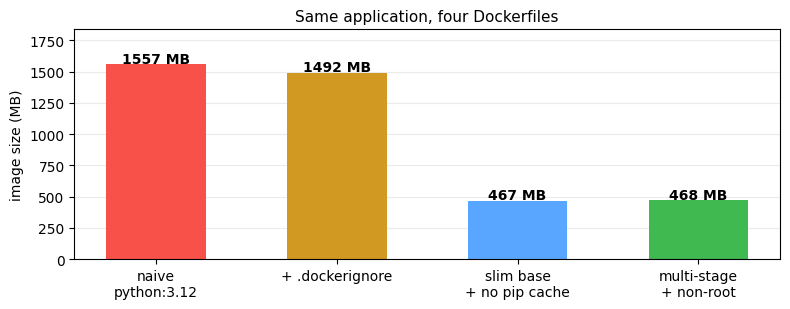

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
names = ["naive\npython:3.12", "+ .dockerignore", "slim base\n+ no pip cache", "multi-stage\n+ non-root"]
vals = [mb(s_naive), mb(s_ignored), mb(s_slim), mb(s_multi)]
fig, ax = plt.subplots(figsize=(8, 3.2))
bars = ax.bar(names, vals, color=["#f85149", "#d29922", "#58a6ff", "#3fb950"], width=.55)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+15, f"{v:.0f} MB", ha="center", fontweight="bold")
ax.set_ylabel("image size (MB)"); ax.set_ylim(0, max(vals)*1.18)
ax.set_title("Same application, four Dockerfiles", fontsize=11)
ax.grid(axis="y", alpha=.25); ax.set_axisbelow(True)
fig.tight_layout(); plt.show()

---
# Part 3 — Make it faster   ·   deck slides 18–21

Layers are cached. A layer is rebuilt only when its instruction — or anything it copies —
changes, **and then every layer after it is rebuilt too**.

That single rule is why `COPY requirements.txt` comes before `COPY app/`: your code changes
several times a day, your dependencies change monthly.

To measure this honestly we need a cold baseline, so the first build below uses `--no-cache`.


In [18]:

def build_timed(dockerfile, tag, no_cache=False):
    """Time a build. no_cache=True gives an honest 'from scratch' baseline."""
    cmd = ["docker", "build", "-f", dockerfile, "-t", tag, "."]
    if no_cache:
        cmd.insert(2, "--no-cache")
    t0 = time.perf_counter()
    r = subprocess.run(cmd, capture_output=True, text=True)
    dt = time.perf_counter() - t0
    if r.returncode != 0:
        print(r.stdout[-1500:], r.stderr[-1500:]); raise RuntimeError(f"build failed: {tag}")
    return dt

t_cold = build_timed("Dockerfile.multi", "churn:multi", no_cache=True)
print(f"1. cold build, no cache at all        {t_cold:6.1f}s")


1. cold build, no cache at all          75.4s


**Layer caching**, measured. Build once cold, then three times with different things changed.
The interesting comparison is the last two: changing code versus changing dependencies.

In [19]:

t_warm = build_timed("Dockerfile.multi", "churn:multi")
print(f"2. nothing changed                    {t_warm:6.1f}s   <- every layer cached")


2. nothing changed                       0.2s   <- every layer cached


Now the two changes that actually happen. First a code edit — the thing you do all day.


In [20]:

with open("app/main.py", "a") as f:
    f.write("\n# a one-line change, like any Tuesday\n")

t_code = build_timed("Dockerfile.multi", "churn:multi")
print(f"3. app code changed                   {t_code:6.1f}s   <- deps still cached")


3. app code changed                      0.2s   <- deps still cached


And now a dependency change, which is the expensive one — everything after
`COPY requirements.txt` has to be rebuilt.


In [21]:

import uuid
# A real new dependency -- plus a unique comment. Without the comment, running this
# notebook twice on the same machine finds the layer for THIS exact requirements.txt
# already in Docker's cache, the build takes 0.1s, and the demonstration silently
# stops demonstrating. pip ignores comments; Docker does not.
with open("requirements.txt", "a") as f:
    f.write("python-json-logger==2.0.7\n")          # one small new dependency
    f.write(f"# unique per run: {uuid.uuid4().hex[:8]}\n")

t_deps = build_timed("Dockerfile.multi", "churn:multi")
print(f"4. requirements.txt changed           {t_deps:6.1f}s   <- pip runs again")

print(f"""
    cold build            {t_cold:6.1f}s
    unchanged             {t_warm:6.1f}s
    code change           {t_code:6.1f}s
    dependency change     {t_deps:6.1f}s""")
assert t_deps > t_code, "a dependency change must cost more than a code change"
assert t_warm < t_cold, "a fully cached rebuild must be faster than a cold one"
print("\nThat gap between rows 3 and 4 is what the COPY ordering buys you, every single edit.")


4. requirements.txt changed             90.0s   <- pip runs again

    cold build              75.4s
    unchanged                0.2s
    code change              0.2s
    dependency change       90.0s

That gap between rows 3 and 4 is what the COPY ordering buys you, every single edit.


### The ordering rule, stated once

```dockerfile
COPY requirements.txt .                 # changes rarely
RUN pip install -r requirements.txt     # expensive -- cache this
COPY app/ ./app/                        # changes constantly
```

Reverse those and every one-character code edit reinstalls every dependency. It is the single
most common reason people believe "Docker builds are slow".

> **Honesty note:** the first time this notebook was written, this section compared two
> Dockerfiles and reported that the *wrong* order was faster — because an earlier run had
> already warmed the cache. The numbers were real and the conclusion was nonsense. Hence the
> `--no-cache` baseline above: a benchmark whose starting state you do not control is not a
> benchmark.


---
# Part 4 — Run it   ·   deck slides 22–24

An image is a file. A **container** is that image running. The flags below are almost the whole
job.

In [22]:
import socket, time, urllib.request, json, subprocess

def free_port(start=8200):
    for p in range(start, start+60):
        with socket.socket() as s:
            if s.connect_ex(("127.0.0.1", p)) != 0: return p

PORT = free_port()
NAME = "churn-demo"
subprocess.run(["docker", "rm", "-f", NAME], capture_output=True)

run = subprocess.run(
    ["docker", "run", "-d", "--name", NAME,
     "-p", f"{PORT}:8000",                     # host port : container port
     "-e", "MODEL_PATH=/srv/app/model.joblib",  # config by environment
     "--memory", "1g", "--cpus", "1.5",        # never let one container eat the host
     "churn:multi"],
    capture_output=True, text=True)
print("container:", run.stdout.strip()[:12] or run.stderr[-300:])

for _ in range(60):
    try:
        urllib.request.urlopen(f"http://127.0.0.1:{PORT}/health", timeout=1); break
    except Exception: time.sleep(0.5)
print(f"serving on http://127.0.0.1:{PORT}")

container: 5121a39c877a
serving on http://127.0.0.1:8200


Talk to the container over HTTP, from outside. This is the moment it stops being a build
exercise and becomes a service.

In [23]:
import requests
print("GET /health :", requests.get(f"http://127.0.0.1:{PORT}/health").json())
r = requests.post(f"http://127.0.0.1:{PORT}/predict",
                  json={"tenure_months": 2, "monthly_charge": 110.0,
                        "support_calls": 8, "plan": "basic"})
print("POST /predict:", r.status_code, r.json())
print("\nThat prediction came from inside a container -- no Python on the host involved.")

GET /health : {'status': 'ok', 'model_loaded': True, 'model_version': '1.0.0'}
POST /predict: 200 {'churn': True, 'probability': 1.0, 'model_version': '1.0.0'}

That prediction came from inside a container -- no Python on the host involved.


Two checks that matter in production: is it running, and is it running as **root**? A container
running as root that gets broken into is a much worse day.

In [24]:
!docker ps --filter name=churn-demo --format 'table {{.Names}}\t{{.Status}}\t{{.Ports}}'
print("\n--- is it running as root? ---")
!docker exec churn-demo id
print("\n--- logs (the same stdout your app writes) ---")
!docker logs --tail 4 churn-demo

{.Names}   {.Status}   {.Ports}
{.Names}   {.Status}   {.Ports}

--- is it running as root? ---
uid=10001(appuser) gid=10001(appuser) groups=10001(appuser)

--- logs (the same stdout your app writes) ---
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)
INFO:     172.17.0.1:47414 - "GET /health HTTP/1.1" 200 OK
INFO:     172.17.0.1:47416 - "GET /health HTTP/1.1" 200 OK
INFO:     172.17.0.1:47428 - "POST /predict HTTP/1.1" 200 OK


### The flags that matter

| Flag | Why |
|---|---|
| `-p 8080:8000` | host:container. Nothing reaches the container without this |
| `-e KEY=value` | configuration. Never bake config into an image |
| `-v ./models:/srv/models` | mount a model from outside, so a new model does not need a new image |
| `--memory 1g --cpus 1.5` | one container must not be able to take down the host |
| `-d` | detached. Without it your terminal is the container's |
| `--rm` | delete on exit — good for one-shot jobs |
| `--restart unless-stopped` | survive a daemon restart |

---
# Part 5 — Compose, and shipping   ·   deck slides 25–27

`docker compose` describes containers in a file instead of in your shell history. One command
brings the whole set up, with a network between them.

In [25]:
%%writefile compose.yaml
services:
  api:
    build:
      context: .
      dockerfile: Dockerfile.multi
    image: churn:multi
    ports: ["8000:8000"]
    environment:
      MODEL_PATH: /srv/app/model.joblib
    volumes:
      - ./app/model.joblib:/srv/app/model.joblib:ro   # swap the model without rebuilding
    healthcheck:
      test: ["CMD", "python", "-c",
             "import urllib.request;urllib.request.urlopen('http://127.0.0.1:8000/health')"]
      interval: 30s
      timeout: 3s
      start_period: 10s
    deploy:
      resources:
        limits: {cpus: "1.5", memory: 1g}
    restart: unless-stopped

Writing compose.yaml


`docker compose` describes the same run as a file instead of a long command line. `config
--quiet` validates it without starting anything.

In [26]:
!docker compose -f compose.yaml config --quiet && echo "compose file is valid"
print()
!docker compose -f compose.yaml config | head -20

compose file is valid

name: docker_demo
services:
  api:
    build:
      context: /home/shamaseen/Desktop/Shai/qafza/free_Training/qafza-free-traning/04-docker/docker_demo
      dockerfile: Dockerfile.multi
    deploy:
      resources:
        limits:
          cpus: 1.5
          memory: "1073741824"
    environment:
      MODEL_PATH: /srv/app/model.joblib
    healthcheck:
      test:
        - CMD
        - python
        - -c
        - import urllib.request;urllib.request.urlopen('http://127.0.0.1:8000/health')
      timeout: 3s


```bash
docker compose up -d          # start everything, build if needed
docker compose ps             # what is running
docker compose logs -f api    # follow one service
docker compose down           # stop and remove
```

Session 10 adds Prometheus and Grafana to this same file, which is where compose starts to
earn its place: three services, one network, one command.

### Getting the image somewhere else

```bash
docker tag churn:multi ghcr.io/acme/churn:1.0.0
docker push          ghcr.io/acme/churn:1.0.0

# and on the other machine
docker pull ghcr.io/acme/churn:1.0.0
```

| Habit | Why |
|---|---|
| tag with a **version**, never only `latest` | `latest` is not a version; you cannot roll back to it |
| include the git SHA — `churn:1.0.0-a1b2c3d` | ties a running container to a commit |
| build the image in CI, not on a laptop | the same artifact goes to staging and production |
| scan it — `docker scout cves`, `trivy` | base images accumulate CVEs while you sleep |

---
# Reference — worth knowing, not demonstrated here

| Topic | One-line version |
|---|---|
| Image vs container vs layer | image is a file, container is it running, layer is one instruction's output |
| `CMD` vs `ENTRYPOINT` | `ENTRYPOINT` is the program, `CMD` the default arguments |
| Alpine and musl | tiny, but wheels often do not exist — expect long builds or subtle bugs |
| Volumes vs bind mounts | volumes for data Docker manages, bind mounts for files you edit |
| Registries and auth | `docker login ghcr.io`; use a token, never a password |
| Vulnerability scanning | `docker scout cves churn:multi`, or trivy in CI |
| GPU containers | `--gpus all` plus the NVIDIA container toolkit |

## Recap

| You wanted to… | Do this |
|---|---|
| stop shipping `.git` and notebooks | a `.dockerignore` |
| a much smaller image | `python:3.x-slim` + `--no-cache-dir` |
| leave the build tooling behind | multi-stage: `COPY --from=builder` |
| rebuild in a second, not a minute | `COPY requirements.txt` **before** `COPY app/` |
| not run as root | `useradd` + `USER appuser` |
| let the orchestrator know you are alive | `HEALTHCHECK` |
| configure without rebuilding | `-e` / `ENV` |
| change the model without rebuilding | mount it as a read-only volume |
| protect the host | `--memory`, `--cpus` |
| describe it all once | `compose.yaml` |

## What to do at work tomorrow

1. Add a `.dockerignore`. It is one file and it usually removes hundreds of megabytes.
2. Move `COPY requirements.txt` above `COPY .` — the cheapest build-time win there is.
3. Switch the base to `-slim` and rebuild. Measure both sizes and write them down.
4. Add `USER appuser`. Root in a container is a habit worth breaking early.
5. Tag with a version and a git SHA, and push from CI rather than from your laptop.

## Cleanup

Stops the container and removes the images built here, so this notebook leaves nothing behind.

In [27]:
import os, shutil, subprocess
subprocess.run(["docker", "rm", "-f", "churn-demo"], capture_output=True)
for tag in ["churn:naive", "churn:ignored", "churn:slim", "churn:multi"]:
    subprocess.run(["docker", "rmi", "-f", tag], capture_output=True)
print("containers and images removed")
!docker images --filter reference='churn:*' --format '{{.Repository}}:{{.Tag}}' | wc -l

os.chdir(BASE)
shutil.rmtree(PROJ, ignore_errors=True)
print("sandbox removed")

containers and images removed
0
sandbox removed
